In [1]:
import json
import sys
import time
import warnings
import zlib
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

try:
    from scipy.stats import wasserstein_distance_nd

    _HAS_WASSERSTEIN = True
except Exception:
    _HAS_WASSERSTEIN = False


def find_project_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()
    current = start
    while current != current.parent:
        if all((current / d).exists() for d in ["data", "utils", "training"]):
            return current
        current = current.parent
    raise RuntimeError(
        "Could not find project root containing data/, utils/, training/."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.fingerprints import compute_fingerprints

print(f"Project root: {PROJECT_ROOT}")
print(f"scipy wasserstein_distance_nd available: {_HAS_WASSERSTEIN}")

Project root: /home/f.capria/drug-discovery-lohi
scipy wasserstein_distance_nd available: True


In [2]:
TASK = "hi"
DATASETS_MAIN = ["drd2", "hiv", "sol"]
DATASETS = DATASETS_MAIN

DATASET_LABELS = {"drd2": "DRD2", "hiv": "HIV", "sol": "Sol"}

SUBSET_FILES = {"F1": "test_3.csv", "F2": "test_2.csv", "F3": "test_1.csv"}
PAIRS = list(combinations(["F1", "F2", "F3"], 2))

PAIR_TO_OUTER_FOLD = {"F1_vs_F2": 1, "F1_vs_F3": 2, "F2_vs_F3": 3}

FP_TYPE = "ecfp4"
EXPECTED_ECFP4_BITS = 2048

K_VALUES = [10, 20, 50, 100, 200]
PAIRWISE_CHUNK_SIZE = 512
N_RANDOM_BIT_REPEATS = 30

VERBOSE_PAIRWISE = False
PRINT_EVERY_RANDOM_REPEAT = 5

RUN_WASSERSTEIN = True
W_SUBSAMPLE = 400

RANDOM_STATE = 42

DATA_ROOT = PROJECT_ROOT / "data" / TASK
OOD_CROSS_DIR = (
    PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / TASK / "cross_dataset"
)
OUT_ROOT = PROJECT_ROOT / "results" / "results_fold_distance_tanimoto" / TASK
FIG_ROOT = OUT_ROOT / "figures"
CACHE_ROOT = PROJECT_ROOT / "features" / "fold_distance_tanimoto" / TASK

for d in (OUT_ROOT, FIG_ROOT, CACHE_ROOT):
    d.mkdir(parents=True, exist_ok=True)

print(f"OUT_ROOT: {OUT_ROOT}")
print(f"FIG_ROOT: {FIG_ROOT}")
print(f"CACHE_ROOT: {CACHE_ROOT}")

OUT_ROOT: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi
FIG_ROOT: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures
CACHE_ROOT: /home/f.capria/drug-discovery-lohi/features/fold_distance_tanimoto/hi


In [3]:
MODEL_NAME_MAP = {
    "Decision Tree": "DT",
    "Logistic Regression": "LR",
    "Linear SVM": "SVM",
    "dt": "DT",
    "decision_tree": "DT",
    "lr": "LR",
    "logistic_regression": "LR",
    "svm": "SVM",
    "svm_linear": "SVM",
    "DT": "DT",
    "LR": "LR",
    "SVM": "SVM",
}

FP_MAP = {
    "ECFP4": "ecfp4",
    "MACCS": "maccs",
    "RDKit desc": "rdkit_desc",
    "ecfp4": "ecfp4",
    "maccs": "maccs",
    "rdkit_desc": "rdkit_desc",
}

IMPORTANCE_COL_CANDIDATES = [
    "importance_value",
    "permutation_importance_mean",
    "abs_weight",
    "normalized_abs_importance",
    "tree_importance",
]

In [4]:
def stable_seed(*parts, base: int = RANDOM_STATE) -> int:
    """Deterministic, cross-platform seed from arbitrary tuple of parts."""
    s = "|".join(str(p) for p in parts) + f"|{base}"
    return zlib.crc32(s.encode("utf-8")) & 0xFFFFFFFF


def local_rng(*parts) -> np.random.Generator:
    return np.random.default_rng(stable_seed(*parts))


def print_section(title: str) -> None:
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def get_smiles_col(df: pd.DataFrame) -> str:
    for col in ["smiles", "SMILES", "canonical_smiles"]:
        if col in df.columns:
            return col
    raise ValueError(f"No SMILES column found. Columns: {df.columns.tolist()}")


def find_importance_col(df: pd.DataFrame) -> str:
    if "importance_value" in df.columns:
        return "importance_value"
    for c in IMPORTANCE_COL_CANDIDATES:
        if c in df.columns:
            return c
    raise ValueError(
        f"No importance column found among {IMPORTANCE_COL_CANDIDATES}. "
        f"Columns: {df.columns.tolist()}"
    )


def normalize_model_name(x) -> str:
    s = str(x).strip()
    return MODEL_NAME_MAP.get(s, s)


def normalize_fingerprint_name(x) -> str:
    s = str(x).strip()
    return FP_MAP.get(s, s)


def protocol_match(x) -> str:
    s = str(x).strip().lower()
    if s in {"ood holdout", "ood_holdout", "holdout_ood", "ood"}:
        return "ood"
    if s in {"random shuffle", "random_shuffle", "random"}:
        return "random"
    if "ood" in s and "random" not in s:
        return "ood"
    if "random" in s:
        return "random"
    return s

In [5]:
def load_subset_fps(dataset: str) -> dict[str, tuple[np.ndarray, pd.DataFrame]]:
    """Read F1/F2/F3 SMILES, compute ECFP4 with cache, drop invalid SMILES."""
    print_section(f"Loading subsets: {dataset.upper()}-{TASK}")

    data_dir = DATA_ROOT / dataset
    cache_dir = CACHE_ROOT / dataset
    cache_dir.mkdir(parents=True, exist_ok=True)

    out = {}
    for subset, fname in SUBSET_FILES.items():
        df = pd.read_csv(data_dir / fname).copy()
        smi_col = get_smiles_col(df)
        smiles = df[smi_col].astype(str).tolist()
        raw_n = len(smiles)

        t0 = time.time()
        X, valid_mask = compute_fingerprints(
            smiles_list=smiles,
            fp_type=FP_TYPE,
            cache_path=str(cache_dir / f"{subset}_{FP_TYPE}.npz"),
        )
        elapsed = time.time() - t0

        valid_mask = np.asarray(valid_mask, dtype=bool)
        if len(valid_mask) != raw_n:
            raise ValueError(
                f"valid_mask length mismatch: {len(valid_mask)} vs {raw_n}"
            )
        df_valid = df.loc[valid_mask].reset_index(drop=True)

        X = np.asarray(X, dtype=np.uint8)
        n_valid = X.shape[0]
        if n_valid != len(df_valid):
            raise ValueError(
                f"X/df mismatch after valid_mask: {n_valid} vs {len(df_valid)}"
            )
        if X.shape[1] != EXPECTED_ECFP4_BITS:
            raise ValueError(
                f"Expected {EXPECTED_ECFP4_BITS} bits, got {X.shape[1]} for {subset}"
            )

        invalid_n = raw_n - n_valid
        print(
            f"  {subset} ({fname}): raw={raw_n}, valid={n_valid}, "
            f"invalid={invalid_n}, n_bits={X.shape[1]}, time={elapsed:.1f}s"
        )

        out[subset] = (X, df_valid)

    return out

## Distance computation choices

- **Full ECFP4** is the baseline structural distance and the reference for everything else.
- **Activity-restricted spaces** (`global_topk`, `ood_topk`, `random_topk`) test whether the shift lies in features that the activity model actually relies on.
- **Random top-k bits** is the negative control: if activity restriction gives the same distance as random restriction of the same dimensionality, the apparent shift in the restricted space is just a dimensionality artefact, not evidence of activity-relevance.
- **Valid-molecule fractions** are required because at small k some molecules may have all-zero restricted fingerprints; restricted-space distances must be interpreted in light of how many molecules actually contribute.


In [6]:
def nn_max_sim(X: np.ndarray, Y: np.ndarray, chunk: int = 512) -> np.ndarray:
    """For each row in X, return max Tanimoto similarity to any row in Y."""
    X = X.astype(np.float32, copy=False)
    Y = Y.astype(np.float32, copy=False)
    sx = X.sum(axis=1)
    sy = Y.sum(axis=1)
    n = X.shape[0]
    out = np.zeros(n, dtype=np.float32)
    for i in range(0, n, chunk):  # chunk for the dimensionality
        block = X[i : i + chunk]
        sb = sx[i : i + chunk]
        dots = block @ Y.T  # intersection
        denom = sb[:, None] + sy[None, :] - dots  # union
        with np.errstate(divide="ignore", invalid="ignore"):
            sim = np.where(denom > 0, dots / denom, 0.0)
        out[i : i + chunk] = sim.max(axis=1)
    return out


def pair_sim(
    X: np.ndarray, Y: np.ndarray, idx_x: np.ndarray, idx_y: np.ndarray
) -> np.ndarray:
    """Tanimoto similarity over a set of paired rows. Returns NaN where union is zero."""
    xa = X[idx_x].astype(np.float32, copy=False)
    yb = Y[idx_y].astype(np.float32, copy=False)
    dots = (xa * yb).sum(axis=1)
    sa = xa.sum(axis=1)
    sb = yb.sum(axis=1)
    denom = sa + sb - dots
    with np.errstate(divide="ignore", invalid="ignore"):
        sim = np.where(denom > 0, dots / denom, np.nan)
    return sim


def nn_distances(XA: np.ndarray, XB: np.ndarray) -> dict:
    """Symmetric nearest-neighbour Tanimoto distance, restricted-space aware."""
    sa = XA.sum(axis=1)
    sb = XB.sum(axis=1)
    valid_a = sa > 0
    valid_b = sb > 0
    n_total_a = int(XA.shape[0])
    n_total_b = int(XB.shape[0])

    XA_v = XA[valid_a]
    XB_v = XB[valid_b]

    if XA_v.shape[0] == 0 or XB_v.shape[0] == 0:
        return {
            "nn_sym_distance": np.nan,
            "nn_A_to_B_mean": np.nan,
            "nn_B_to_A_mean": np.nan,
            "nn_AB_array": np.array([], dtype=np.float32),
            "nn_BA_array": np.array([], dtype=np.float32),
            "n_valid_a": int(valid_a.sum()),
            "n_valid_b": int(valid_b.sum()),
            "n_total_a": n_total_a,
            "n_total_b": n_total_b,
        }

    # to maintain simmetry
    sim_AB = nn_max_sim(XA_v, XB_v)
    sim_BA = nn_max_sim(XB_v, XA_v)
    d_AB = 1.0 - sim_AB
    d_BA = 1.0 - sim_BA

    return {
        "nn_sym_distance": float(
            0.5 * (d_AB.mean() + d_BA.mean())
        ),  # mean for simmetry
        "nn_A_to_B_mean": float(d_AB.mean()),
        "nn_B_to_A_mean": float(d_BA.mean()),
        "nn_AB_array": d_AB,
        "nn_BA_array": d_BA,
        "n_valid_a": int(valid_a.sum()),
        "n_valid_b": int(valid_b.sum()),
        "n_total_a": n_total_a,
        "n_total_b": n_total_b,
    }


def complete_pairwise_distance(
    XA: np.ndarray,
    XB: np.ndarray,
    dataset: str,
    pair: str,
    space: str,
    chunk: int = PAIRWISE_CHUNK_SIZE,
) -> dict:
    """
    Complete cross-fold pairwise Tanimoto distance.

    Computes the mean Tanimoto distance over all pairs:
        x in XA, y in XB

    Pairs with zero union are ignored and counted through valid_pair_fraction.
    """
    XA = XA.astype(np.float32, copy=False)
    XB = XB.astype(np.float32, copy=False)

    sum_dist = 0.0
    n_valid = 0
    n_total = int(XA.shape[0] * XB.shape[0])
    if VERBOSE_PAIRWISE:
        print(
            f"      pairwise {dataset} | {pair} | {space}: "
            f"{XA.shape[0]} x {XB.shape[0]} = {n_total:,} pairs"
        )

    y_sum = XB.sum(axis=1)

    for start in range(0, XA.shape[0], chunk):
        xb = XA[start : start + chunk]
        x_sum = xb.sum(axis=1)

        inter = xb @ XB.T
        union = x_sum[:, None] + y_sum[None, :] - inter

        valid = union > 0

        sim = np.zeros_like(inter, dtype=np.float32)
        np.divide(inter, union, out=sim, where=valid)

        dist = 1.0 - sim

        sum_dist += float(dist[valid].sum())
        n_valid += int(valid.sum())

    mean_dist = sum_dist / n_valid if n_valid > 0 else np.nan

    if VERBOSE_PAIRWISE:
        print(
            f"        done: mean={mean_dist:.4f}, "
            f"valid_pairs={n_valid:,}/{n_total:,} "
            f"({n_valid / n_total:.3f})"
        )

    return {
        "pairwise_distance": mean_dist,
        "n_valid_pairs": n_valid,
        "n_total_pairs": n_total,
        "valid_pair_fraction": n_valid / n_total if n_total > 0 else np.nan,
        "pairwise_mode": "complete",
    }

## Load list A --> activity relevant features


In [7]:
def load_list_a() -> pd.DataFrame:
    """Load List A activity feature importance, normalised and ECFP4-only."""
    print_section("Loading List A")

    path = OOD_CROSS_DIR / "cross_dataset_feature_importance_all.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing List A file: {path}")

    df = pd.read_csv(path, low_memory=False).copy()
    print(f"Raw List A: {df.shape}")

    df["dataset"] = df["dataset"].astype(str).str.lower()
    df = df[df["dataset"].isin(DATASETS_MAIN)].copy()

    df["model"] = df["model"].map(lambda x: normalize_model_name(x)).astype(str)
    df["fingerprint"] = (
        df["fingerprint"].map(lambda x: normalize_fingerprint_name(x)).astype(str)
    )
    df = df[df["fingerprint"] == "ecfp4"].copy()

    imp_col = find_importance_col(df)
    print(f"Using importance column: {imp_col}")

    df["importance_value_numeric"] = df[imp_col].fillna(0).astype(float)

    df["abs_importance"] = np.where(
        df["model"].eq("DT"),
        df["importance_value_numeric"].clip(lower=0.0),
        df["importance_value_numeric"].abs(),
    )

    df["feature_idx"] = df["feature_idx"].astype(int)
    df["fold"] = df["fold"].astype(int)
    df["protocol_norm"] = df["protocol"].map(protocol_match)

    print(f"Filtered List A: {df.shape}")
    print(f"Datasets : {sorted(df['dataset'].unique())}")
    print(f"Models   : {sorted(df['model'].unique())}")
    print(f"Protocols: {sorted(df['protocol_norm'].unique())}")
    print(f"Folds    : {sorted(df['fold'].unique())}")
    print("Rows by dataset/model:")
    print(
        df.groupby(["dataset", "model"])
        .size()
        .rename("n_rows")
        .reset_index()
        .to_string(index=False)
    )

    return df

## Best models


In [8]:
def best_ecfp4_activity_models() -> dict[str, str]:
    """Choose one best ECFP4 activity model per dataset by mean final test PR-AUC."""
    print_section("Selecting best ECFP4 activity model per dataset")

    path = OOD_CROSS_DIR / "cross_dataset_protocol_summary.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing protocol summary: {path}")

    df = pd.read_csv(path).copy()
    df["dataset"] = df["dataset"].astype(str).str.lower()
    df = df[df["dataset"].isin(DATASETS_MAIN)].copy()
    df["model"] = df["model"].map(normalize_model_name).astype(str)
    df["fingerprint"] = df["fingerprint"].map(normalize_fingerprint_name).astype(str)
    df = df[df["fingerprint"] == "ecfp4"].copy()

    if "test_mean" in df.columns:
        score_col = "test_mean"
    elif "test_pr_auc_mean" in df.columns:
        score_col = "test_pr_auc_mean"
    else:
        raise ValueError(
            "No score column found among {test_mean, test_pr_auc_mean}. "
            f"Columns: {df.columns.tolist()}"
        )
    print(f"Using score column: {score_col}")

    agg = (
        df.groupby(["dataset", "model"], as_index=False)[score_col]
        .mean()
        .sort_values(["dataset", score_col], ascending=[True, False])
    )
    print("\nMean ECFP4 test score by dataset/model:")
    print(agg.to_string(index=False))

    best = (
        agg.sort_values([score_col], ascending=False)
        .groupby("dataset")
        .head(1)
        .set_index("dataset")["model"]
        .to_dict()
    )
    print("\nBest ECFP4 model per dataset:")
    for d, m in best.items():
        print(f"  {d}: {m}")

    return best

In [9]:
def topk_bits_global(
    list_a: pd.DataFrame, dataset: str, model: str, k: int
) -> np.ndarray:
    """Top-k ECFP4 bits pooled across protocols and folds for one (dataset, model)."""
    sub = list_a[(list_a["dataset"] == dataset) & (list_a["model"] == model)]
    if sub.empty:
        return np.array([], dtype=int)
    agg = (
        sub.groupby("feature_idx")["abs_importance"].mean().sort_values(ascending=False)
    )
    return agg.head(k).index.to_numpy(dtype=int)


def topk_bits_fold_protocol(
    list_a: pd.DataFrame,
    dataset: str,
    model: str,
    fold: int,
    protocol: str,
    k: int,
) -> np.ndarray:
    """Top-k ECFP4 bits for (dataset, model, fold, protocol) — fold/protocol-aware."""
    protocol = protocol_match(protocol)
    sub = list_a[
        (list_a["dataset"] == dataset)
        & (list_a["model"] == model)
        & (list_a["fold"].astype(int) == int(fold))
        & (list_a["protocol_norm"] == protocol)
    ]
    if sub.empty:
        return np.array([], dtype=int)
    agg = (
        sub.groupby("feature_idx")["abs_importance"].mean().sort_values(ascending=False)
    )
    return agg.head(k).index.to_numpy(dtype=int)


def random_topk_bits(dataset: str, pair: str, k: int, repeat: int) -> np.ndarray:
    """Random subset of k ECFP4 bits, deterministic by (dataset, pair, k, repeat)."""
    rng = local_rng("random_bits", dataset, pair, k, repeat)
    return rng.choice(EXPECTED_ECFP4_BITS, size=k, replace=False)

In [10]:
def restrict_to_bits(X: np.ndarray, bits: np.ndarray) -> np.ndarray:
    if len(bits) == 0:
        return np.zeros((X.shape[0], 0), dtype=X.dtype)
    return X[:, bits]


def wasserstein_nd_optional(
    XA: np.ndarray,
    XB: np.ndarray,
    n: int,
    dataset: str,
    pair: str,
    space: str,
) -> float:
    """Optional ND Wasserstein-1 distance with Euclidean ground metric. Disabled by default."""
    if not RUN_WASSERSTEIN or not _HAS_WASSERSTEIN:
        return np.nan
    rng = local_rng("wasserstein", dataset, pair, space)
    if XA.shape[0] > n:
        XA = XA[rng.choice(XA.shape[0], size=n, replace=False)]
    if XB.shape[0] > n:
        XB = XB[rng.choice(XB.shape[0], size=n, replace=False)]
    try:
        return float(
            wasserstein_distance_nd(XA.astype(np.float32), XB.astype(np.float32))
        )
    except Exception as exc:
        warnings.warn(f"Wasserstein failed for {dataset}|{pair}|{space}: {exc}")
        return np.nan

In [11]:
DIST_ROW_KEYS = [
    "dataset",
    "dataset_label",
    "pair",
    "space",
    "k",
    "model",
    "bit_source",
    "activity_protocol",
    "activity_fold",
    "bit_repeat",
    "bits_used",
    "nn_sym_distance",
    "nn_A_to_B_mean",
    "nn_B_to_A_mean",
    "wasserstein_nd",
    "valid_molecule_fraction",
    "n_valid_molecules",
    "n_total_molecules",
    "pairwise_distance",
    "valid_pair_fraction",
    "n_valid_pairs",
    "n_total_pairs",
    "pairwise_mode",
]


def _base_row(
    dataset,
    pair,
    space,
    k,
    model,
    bit_source,
    activity_protocol,
    activity_fold,
    bit_repeat,
    bits_used,
):
    return {
        "dataset": dataset,
        "dataset_label": DATASET_LABELS.get(dataset, dataset),
        "pair": pair,
        "space": space,
        "k": int(k),
        "model": model,
        "bit_source": bit_source,
        "activity_protocol": activity_protocol,
        "activity_fold": activity_fold,
        "bit_repeat": bit_repeat,
        "bits_used": int(bits_used),
    }


def add_distance_row(
    dist_rows,
    hist_rows,
    dataset,
    pair,
    XA,
    XB,
    model,
):
    """Full ECFP4 space row."""
    space = "full_ecfp4"
    bit_source = "full_ecfp4"
    nn = nn_distances(XA, XB)
    pw = complete_pairwise_distance(
        XA,
        XB,
        dataset=dataset,
        pair=pair,
        space=space,
    )
    wd = wasserstein_nd_optional(XA, XB, W_SUBSAMPLE, dataset, pair, space)

    n_valid_mol = nn["n_valid_a"] + nn["n_valid_b"]
    n_total_mol = nn["n_total_a"] + nn["n_total_b"]

    row = _base_row(
        dataset,
        pair,
        space,
        EXPECTED_ECFP4_BITS,
        model,
        bit_source,
        np.nan,
        np.nan,
        np.nan,
        EXPECTED_ECFP4_BITS,
    )
    row.update(
        {
            "nn_sym_distance": nn["nn_sym_distance"],
            "nn_A_to_B_mean": nn["nn_A_to_B_mean"],
            "nn_B_to_A_mean": nn["nn_B_to_A_mean"],
            "wasserstein_nd": wd,
            "valid_molecule_fraction": n_valid_mol / max(n_total_mol, 1),
            "n_valid_molecules": n_valid_mol,
            "n_total_molecules": n_total_mol,
            "pairwise_distance": pw["pairwise_distance"],
            "valid_pair_fraction": pw["valid_pair_fraction"],
            "n_valid_pairs": pw["n_valid_pairs"],
            "n_total_pairs": pw["n_total_pairs"],
            "pairwise_mode": pw["pairwise_mode"],
        }
    )
    dist_rows.append(row)

    for d in nn["nn_AB_array"]:
        hist_rows.append(
            {
                "dataset": dataset,
                "pair": pair,
                "space": space,
                "k": EXPECTED_ECFP4_BITS,
                "bit_source": bit_source,
                "direction": "A_to_B",
                "nn_distance": float(d),
            }
        )
    for d in nn["nn_BA_array"]:
        hist_rows.append(
            {
                "dataset": dataset,
                "pair": pair,
                "space": space,
                "k": EXPECTED_ECFP4_BITS,
                "bit_source": bit_source,
                "direction": "B_to_A",
                "nn_distance": float(d),
            }
        )


def add_restricted_distance_row(
    dist_rows,
    hist_rows,
    dataset,
    pair,
    XA,
    XB,
    bits,
    k,
    model,
    space,
    bit_source,
    activity_protocol,
    activity_fold,
    bit_repeat,
    store_hist: bool,
):
    """Top-k restricted space row."""
    if len(bits) == 0 and bit_source in {
        "global_activity",
        "ood_activity",
        "random_shuffle_activity",
    }:
        warnings.warn(
            f"No activity bits found for {dataset} | {pair} | {space} | "
            f"model={model} | bit_source={bit_source}. "
            "Distances will be NaN or based on empty restricted fingerprints."
        )
    XA_r = restrict_to_bits(XA, bits)
    XB_r = restrict_to_bits(XB, bits)

    nn = nn_distances(XA_r, XB_r)
    pw = complete_pairwise_distance(
        XA_r,
        XB_r,
        dataset=dataset,
        pair=pair,
        space=space,
    )
    wd = wasserstein_nd_optional(XA_r, XB_r, W_SUBSAMPLE, dataset, pair, space)

    n_valid_mol = nn["n_valid_a"] + nn["n_valid_b"]
    n_total_mol = nn["n_total_a"] + nn["n_total_b"]

    row = _base_row(
        dataset,
        pair,
        space,
        k,
        model,
        bit_source,
        activity_protocol,
        activity_fold,
        bit_repeat,
        len(bits),
    )
    row.update(
        {
            "nn_sym_distance": nn["nn_sym_distance"],
            "nn_A_to_B_mean": nn["nn_A_to_B_mean"],
            "nn_B_to_A_mean": nn["nn_B_to_A_mean"],
            "wasserstein_nd": wd,
            "valid_molecule_fraction": n_valid_mol / max(n_total_mol, 1),
            "n_valid_molecules": n_valid_mol,
            "n_total_molecules": n_total_mol,
            "pairwise_distance": pw["pairwise_distance"],
            "valid_pair_fraction": pw["valid_pair_fraction"],
            "n_valid_pairs": pw["n_valid_pairs"],
            "n_total_pairs": pw["n_total_pairs"],
            "pairwise_mode": pw["pairwise_mode"],
        }
    )
    dist_rows.append(row)

    if store_hist:
        for d in nn["nn_AB_array"]:
            hist_rows.append(
                {
                    "dataset": dataset,
                    "pair": pair,
                    "space": space,
                    "k": k,
                    "bit_source": bit_source,
                    "direction": "A_to_B",
                    "nn_distance": float(d),
                }
            )
        for d in nn["nn_BA_array"]:
            hist_rows.append(
                {
                    "dataset": dataset,
                    "pair": pair,
                    "space": space,
                    "k": k,
                    "bit_source": bit_source,
                    "direction": "B_to_A",
                    "nn_distance": float(d),
                }
            )

### COmpute dataset distances


In [12]:
def compute_dataset_distances(
    dataset: str,
    fps: dict[str, tuple[np.ndarray, pd.DataFrame]],
    list_a: pd.DataFrame,
    best_model: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    print_section(f"Computing distances: {dataset.upper()}-{TASK} (model={best_model})")
    dist_rows: list[dict] = []
    hist_rows: list[dict] = []

    for fold_a, fold_b in PAIRS:
        pair = f"{fold_a}_vs_{fold_b}"
        outer_fold = PAIR_TO_OUTER_FOLD[pair]
        XA, _ = fps[fold_a]
        XB, _ = fps[fold_b]
        print(
            f"\n  Pair {pair} (outer fold {outer_fold}): nA={XA.shape[0]} nB={XB.shape[0]}"
        )

        # A. Full ECFP4
        add_distance_row(dist_rows, hist_rows, dataset, pair, XA, XB, best_model)

        # B/C/D. Restricted top-k spaces
        for k in K_VALUES:
            print(f"    k={k}: activity spaces + random-bit baseline")
            # B. Global activity bits (pooled across protocols and folds)
            bits_g = topk_bits_global(list_a, dataset, best_model, k)
            print(f"      global_activity: {len(bits_g)} bits")
            add_restricted_distance_row(
                dist_rows,
                hist_rows,
                dataset,
                pair,
                XA,
                XB,
                bits=bits_g,
                k=k,
                model=best_model,
                space=f"global_top{k}",
                bit_source="global_activity",
                activity_protocol="pooled",
                activity_fold=np.nan,
                bit_repeat=np.nan,
                store_hist=True,
            )

            # C. OOD activity bits, fold-aware
            bits_ood = topk_bits_fold_protocol(
                list_a, dataset, best_model, outer_fold, "ood", k
            )
            print(f"      ood_activity fold={outer_fold}: {len(bits_ood)} bits")
            add_restricted_distance_row(
                dist_rows,
                hist_rows,
                dataset,
                pair,
                XA,
                XB,
                bits=bits_ood,
                k=k,
                model=best_model,
                space=f"ood_top{k}",
                bit_source="ood_activity",
                activity_protocol="ood",
                activity_fold=outer_fold,
                bit_repeat=np.nan,
                store_hist=True,
            )

            # C. Random-shuffle activity bits, fold-aware
            bits_rnd = topk_bits_fold_protocol(
                list_a, dataset, best_model, outer_fold, "random", k
            )
            print(
                f"      random_shuffle_activity fold={outer_fold}: {len(bits_rnd)} bits"
            )
            add_restricted_distance_row(
                dist_rows,
                hist_rows,
                dataset,
                pair,
                XA,
                XB,
                bits=bits_rnd,
                k=k,
                model=best_model,
                space=f"random_top{k}",
                bit_source="random_shuffle_activity",
                activity_protocol="random",
                activity_fold=outer_fold,
                bit_repeat=np.nan,
                store_hist=True,
            )

            # D. Random-bit baseline (negative control for dimensionality)
            for r in range(N_RANDOM_BIT_REPEATS):
                if (
                    r == 0
                    or (r + 1) % PRINT_EVERY_RANDOM_REPEAT == 0
                    or r == N_RANDOM_BIT_REPEATS - 1
                ):
                    print(f"      random_bits repeat {r + 1}/{N_RANDOM_BIT_REPEATS}")
                bits_rb = random_topk_bits(dataset, pair, k, r)
                add_restricted_distance_row(
                    dist_rows,
                    hist_rows,
                    dataset,
                    pair,
                    XA,
                    XB,
                    bits=bits_rb,
                    k=k,
                    model=best_model,
                    space=f"random_bits_top{k}",
                    bit_source="random_bits",
                    activity_protocol=np.nan,
                    activity_fold=np.nan,
                    bit_repeat=r,
                    store_hist=False,
                )

    dist_df = pd.DataFrame(dist_rows)
    hist_df = pd.DataFrame(hist_rows)

    n_random_bit_rows = (dist_df["bit_source"] == "random_bits").sum()
    expected_rb = len(PAIRS) * len(K_VALUES) * N_RANDOM_BIT_REPEATS
    print(f"\n  Dataset {dataset}: dist_rows={len(dist_df)}, hist_rows={len(hist_df)}")
    print(
        f"  random_bits rows = {n_random_bit_rows} (expected {expected_rb}: "
        f"{len(PAIRS)} pairs × {len(K_VALUES)} k × {N_RANDOM_BIT_REPEATS} repeats)"
    )

    expected_total = len(PAIRS) * (
        1 + len(K_VALUES) * (1 + 1 + 1 + N_RANDOM_BIT_REPEATS)
    )
    if len(dist_df) != expected_total:
        warnings.warn(
            f"{dataset}: got {len(dist_df)} dist rows, expected {expected_total}"
        )

    return dist_df, hist_df

## Expected interpretation

- If activity top-k distance **differs** from the random-bit top-k baseline (outside its [Q05, Q95] envelope), the activity restriction is doing something other than dimensionality reduction — it is picking out a subspace where the fold shift behaves differently.
- If OOD-activity bits and random-shuffle-activity bits give **different distances**, the two validation protocols select activity models that lean on different shift-related feature subspaces.
- If `valid_molecule_fraction` is low for small k, restricted-space distances for those k must be read cautiously: the average is over the molecules that retain non-empty restricted fingerprints, which can be a biased subsample of the fold.


In [13]:
def set_plot_style():
    mpl.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "font.size": 9,
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.labelsize": 8.5,
            "ytick.labelsize": 8.5,
            "legend.fontsize": 8.5,
            "figure.dpi": 150,
            "savefig.dpi": 600,
            "axes.linewidth": 0.8,
            "axes.spines.top": False,
            "axes.spines.right": False,
        }
    )


DATASET_COLORS = {"drd2": "#4C78A8", "hiv": "#F58518", "sol": "#B279A2"}

In [14]:
def fig_distance_histograms(
    hist_all: pd.DataFrame, k_show: int = 50, source_prefix: str = "global"
):
    set_plot_style()
    datasets = [d for d in DATASETS if d in hist_all["dataset"].unique()]
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.4), sharey=True, squeeze=False)

    restricted_space = f"{source_prefix}_top{k_show}"

    for ax, ds in zip(axes[0], datasets):
        full = hist_all[
            (hist_all["dataset"] == ds) & (hist_all["space"] == "full_ecfp4")
        ]
        rest = hist_all[
            (hist_all["dataset"] == ds) & (hist_all["space"] == restricted_space)
        ]

        if len(full) > 0:
            ax.hist(
                full["nn_distance"],
                bins=40,
                alpha=0.55,
                color="#7F8C8D",
                label="Full ECFP4",
                density=True,
            )
            ax.axvline(full["nn_distance"].mean(), ls="--", lw=1.2, color="#34495E")

        if len(rest) > 0:
            ax.hist(
                rest["nn_distance"],
                bins=40,
                alpha=0.55,
                color=DATASET_COLORS.get(ds, "C0"),
                label=f"{restricted_space}",
                density=True,
            )
            ax.axvline(
                rest["nn_distance"].mean(),
                ls="--",
                lw=1.2,
                color=DATASET_COLORS.get(ds, "C0"),
            )

        ax.set_title(DATASET_LABELS.get(ds, ds), fontweight="bold")
        ax.set_xlabel("Nearest-neighbour Tanimoto distance")
        ax.legend(loc="upper left", frameon=False)
        ax.grid(axis="y", ls="--", alpha=0.4)

    axes[0, 0].set_ylabel("Density")
    fig.suptitle(
        f"Diagnostic NN distance distribution: full ECFP4 vs {source_prefix} top-{k_show}",
        fontweight="bold",
        y=1.03,
    )
    fig.tight_layout()
    fname = FIG_ROOT / f"fig1_nn_hist_full_vs_{source_prefix}_top{k_show}"
    fig.savefig(f"{fname}.png", bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [15]:
def fig_distance_vs_k(dist_all: pd.DataFrame, source_prefix: str = "global"):
    set_plot_style()

    src_map = {
        "global": "global_activity",
        "ood": "ood_activity",
        "random": "random_shuffle_activity",
    }
    bit_src = src_map[source_prefix]

    sub = dist_all[dist_all["bit_source"] == bit_src]
    full = dist_all[dist_all["bit_source"] == "full_ecfp4"]

    fig, ax = plt.subplots(figsize=(6.0, 4.2))
    for ds in DATASETS:
        sub_d = (
            sub[sub["dataset"] == ds]
            .groupby("k", as_index=False)["pairwise_distance"]
            .mean()
            .sort_values("k")
        )
        if sub_d.empty:
            continue
        ax.plot(
            sub_d["k"],
            sub_d["pairwise_distance"],
            marker="o",
            lw=1.8,
            color=DATASET_COLORS.get(ds, "C0"),
            label=DATASET_LABELS[ds],
        )

        full_d = full[full["dataset"] == ds]["pairwise_distance"].mean()
        if np.isfinite(full_d):
            ax.axhline(
                full_d, ls="--", lw=0.9, color=DATASET_COLORS.get(ds, "C0"), alpha=0.7
            )

    ax.set_xscale("log")
    ax.set_xticks(K_VALUES)
    ax.set_xticklabels([str(k) for k in K_VALUES])
    ax.set_xlabel("Top-k ECFP4 bits (log scale)")
    ax.set_ylabel("Mean complete pairwise Tanimoto distance")
    ax.set_title(
        f"Complete pairwise distance vs k — {source_prefix} activity bits "
        "(dashed = full ECFP4)",
        fontweight="bold",
    )
    ax.grid(ls="--", alpha=0.4)
    ax.legend(frameon=False)

    fname = FIG_ROOT / f"fig2_pairwise_distance_vs_k_{source_prefix}"
    fig.tight_layout()
    fig.savefig(f"{fname}.png", bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [16]:
def fig_protocol_vs_k(dist_all: pd.DataFrame):
    set_plot_style()
    datasets = [d for d in DATASETS if d in dist_all["dataset"].unique()]
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.6), sharey=True, squeeze=False)

    full = dist_all[dist_all["bit_source"] == "full_ecfp4"]

    for ax, ds in zip(axes[0], datasets):
        for src, label, color in [
            ("ood_activity", "OOD activity bits", "#2563EB"),
            ("random_shuffle_activity", "Random-shuffle activity bits", "#DC2626"),
        ]:
            sub = (
                dist_all[(dist_all["dataset"] == ds) & (dist_all["bit_source"] == src)]
                .groupby("k", as_index=False)["pairwise_distance"]
                .mean()
                .sort_values("k")
            )
            if sub.empty:
                continue
            ax.plot(
                sub["k"],
                sub["pairwise_distance"],
                marker="o",
                lw=1.8,
                color=color,
                label=label,
            )

        # Full ECFP4 reference: one line per dataset axis, OUTSIDE inner loop.
        full_d = full[full["dataset"] == ds]["pairwise_distance"].mean()
        if np.isfinite(full_d):
            ax.axhline(full_d, ls="--", lw=1.0, color="#7F8C8D", label="Full ECFP4")

        ax.set_xscale("log")
        ax.set_xticks(K_VALUES)
        ax.set_xticklabels([str(k) for k in K_VALUES])
        ax.set_title(DATASET_LABELS.get(ds, ds), fontweight="bold")
        ax.set_xlabel("Top-k bits (log scale)")
        ax.grid(ls="--", alpha=0.4)
        ax.legend(frameon=False, fontsize=8)

    axes[0, 0].set_ylabel("Mean complete pairwise Tanimoto distance")
    fig.suptitle(
        "OOD vs random-shuffle activity bits — complete pairwise distance vs k",
        fontweight="bold",
        y=1.03,
    )
    fig.tight_layout()
    fname = FIG_ROOT / "fig3_protocol_vs_k_pairwise"
    fig.savefig(f"{fname}.png", bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [17]:
def fig_delta_heatmap(
    dist_all: pd.DataFrame, k_show: int = 50, source_prefix: str = "global"
):
    set_plot_style()
    src_map = {
        "global": "global_activity",
        "ood": "ood_activity",
        "random": "random_shuffle_activity",
    }
    bit_src = src_map[source_prefix]

    full = dist_all[dist_all["bit_source"] == "full_ecfp4"][
        ["dataset", "pair", "pairwise_distance"]
    ].rename(columns={"pairwise_distance": "full_distance"})

    rest = dist_all[(dist_all["bit_source"] == bit_src) & (dist_all["k"] == k_show)][
        ["dataset", "pair", "pairwise_distance"]
    ].rename(columns={"pairwise_distance": "restricted_distance"})

    merged = rest.merge(full, on=["dataset", "pair"], how="inner")
    merged["delta"] = merged["restricted_distance"] - merged["full_distance"]

    mat = (
        merged.pivot(index="dataset", columns="pair", values="delta")
        .reindex(DATASETS)
        .reindex(columns=[f"{a}_vs_{b}" for a, b in PAIRS])
    )

    vmax = float(np.nanmax(np.abs(mat.values))) or 0.001
    norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(5.6, 3.0))
    cmap = mpl.colormaps["RdBu_r"].copy()
    cmap.set_bad(color="lightgray")
    data = np.ma.masked_invalid(mat.values.astype(float))
    im = ax.imshow(data, cmap=cmap, norm=norm, aspect="auto", interpolation="nearest")

    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=0)
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels([DATASET_LABELS.get(d, d) for d in mat.index])

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iloc[i, j]
            if pd.notna(v):
                ax.text(
                    j,
                    i,
                    f"{v:+.2f}",
                    ha="center",
                    va="center",
                    fontsize=8.5,
                    fontweight="bold",
                    color="white" if abs(v) > 0.6 * vmax else "0.10",
                )

    cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.03)
    cbar.set_label("Δ complete pairwise distance (restricted − full)")
    ax.set_title(
        f"{source_prefix} top-{k_show} minus full ECFP4 — Δ complete pairwise Tanimoto distance",
        fontweight="bold",
        pad=8,
    )
    fig.tight_layout()
    fname = FIG_ROOT / f"fig4_pairwise_delta_heatmap_{source_prefix}_top{k_show}"
    fig.savefig(f"{fname}.png", bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [18]:
def fig_activity_vs_random_bits(dist_all: pd.DataFrame, k_show: int = 50):
    set_plot_style()
    datasets = [d for d in DATASETS if d in dist_all["dataset"].unique()]
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(4.4 * n, 3.6), sharey=True, squeeze=False)

    activity_sources = [
        ("global_activity", "Global activity", "#2C3E50"),
        ("ood_activity", "OOD activity", "#2563EB"),
        ("random_shuffle_activity", "Random-shuffle activity", "#DC2626"),
    ]

    for ax, ds in zip(axes[0], datasets):
        # Random-bit baseline (gray jitter + Q05/Q95 band + mean line at x=0).
        rb = dist_all[
            (dist_all["dataset"] == ds)
            & (dist_all["bit_source"] == "random_bits")
            & (dist_all["k"] == k_show)
        ]
        if not rb.empty:
            jitter = local_rng("jitter", ds, k_show).uniform(-0.18, 0.18, size=len(rb))
            ax.scatter(
                np.zeros(len(rb)) + jitter,
                rb["pairwise_distance"],
                s=14,
                color="#95A5A6",
                alpha=0.55,
                label="Random-bit baseline",
                zorder=2,
            )
            q05 = rb["pairwise_distance"].quantile(0.05)
            q95 = rb["pairwise_distance"].quantile(0.95)
            ax.axhspan(q05, q95, color="#BDC3C7", alpha=0.25, zorder=1)
            ax.hlines(
                rb["pairwise_distance"].mean(),
                -0.4,
                0.4,
                color="#7F8C8D",
                lw=1.4,
                zorder=3,
            )

        # Activity sources (global / OOD / random-shuffle) at x = 1, 2, 3.
        for offset, (src, label, color) in enumerate(activity_sources, start=1):
            sub = dist_all[
                (dist_all["dataset"] == ds)
                & (dist_all["bit_source"] == src)
                & (dist_all["k"] == k_show)
            ]
            if sub.empty:
                continue
            ax.scatter(
                np.full(len(sub), offset),
                sub["pairwise_distance"],
                s=70,
                color=color,
                edgecolor="black",
                linewidth=0.5,
                alpha=0.9,
                zorder=4,
                label=label,
            )
            ax.hlines(
                sub["pairwise_distance"].mean(),
                offset - 0.3,
                offset + 0.3,
                color=color,
                lw=2.0,
                zorder=5,
            )

        # Full ECFP4 reference (constant across x).
        full_d = dist_all[
            (dist_all["dataset"] == ds) & (dist_all["bit_source"] == "full_ecfp4")
        ]["pairwise_distance"].mean()
        if np.isfinite(full_d):
            ax.axhline(
                full_d,
                ls="--",
                lw=1.0,
                color="black",
                alpha=0.6,
                label="Full ECFP4 mean",
            )

        ax.set_xticks([0, 1, 2, 3])
        ax.set_xticklabels(
            [
                "Random\nbits",
                "Global\nactivity",
                "OOD\nactivity",
                "Random-shuffle\nactivity",
            ],
            fontsize=8,
        )
        ax.set_title(DATASET_LABELS.get(ds, ds), fontweight="bold")
        ax.grid(axis="y", ls="--", alpha=0.4)
        if ax is axes[0, 0]:
            ax.set_ylabel(f"Complete pairwise Tanimoto distance @ top-{k_show}")
        ax.legend(loc="lower right", fontsize=7.5, frameon=False)

    fig.suptitle(
        f"Activity top-{k_show} vs random-bit top-{k_show} baseline",
        fontweight="bold",
        y=1.03,
    )
    fig.tight_layout()
    fname = FIG_ROOT / f"fig5_pairwise_activity_vs_random_bits_top{k_show}"
    fig.savefig(f"{fname}.png", bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [19]:
def fig_valid_fraction_vs_k(dist_all: pd.DataFrame):
    set_plot_style()
    datasets = [d for d in DATASETS if d in dist_all["dataset"].unique()]
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.4), sharey=True, squeeze=False)

    series = [
        ("global_activity", "Global activity", "#2C3E50"),
        ("ood_activity", "OOD activity", "#2563EB"),
        ("random_shuffle_activity", "Random-shuffle activity", "#DC2626"),
        ("random_bits", "Random bits", "#95A5A6"),
    ]

    for ax, ds in zip(axes[0], datasets):
        for src, label, color in series:
            sub = (
                dist_all[(dist_all["dataset"] == ds) & (dist_all["bit_source"] == src)]
                .groupby("k", as_index=False)["valid_molecule_fraction"]
                .mean()
                .sort_values("k")
            )
            if sub.empty:
                continue
            ax.plot(
                sub["k"],
                sub["valid_molecule_fraction"],
                marker="o",
                lw=1.6,
                color=color,
                label=label,
            )

        ax.set_xscale("log")
        ax.set_xticks(K_VALUES)
        ax.set_xticklabels([str(k) for k in K_VALUES])
        ax.set_ylim(0, 1.02)
        ax.set_xlabel("Top-k bits (log scale)")
        ax.set_title(DATASET_LABELS.get(ds, ds), fontweight="bold")
        ax.grid(ls="--", alpha=0.4)
        ax.legend(frameon=False, fontsize=7.5)

    axes[0, 0].set_ylabel("Valid molecule fraction")
    fig.suptitle(
        "Restricted-space coverage: valid molecule fraction vs k",
        fontweight="bold",
        y=1.03,
    )
    fig.tight_layout()
    fname = FIG_ROOT / "fig6_valid_fraction_vs_k"
    fig.savefig(f"{fname}.png", bbox_inches="tight")
    fig.savefig(f"{fname}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [20]:
def print_output_diagnostics(dist_all: pd.DataFrame, hist_all: pd.DataFrame):
    print_section("Output diagnostics")
    print(f"dist_all shape: {dist_all.shape}")
    print(f"hist_all shape: {hist_all.shape}")

    if len(dist_all) == 0:
        raise RuntimeError("dist_all is empty — distance computation produced no rows.")

    print("\nRows by dataset / bit_source:")
    print(
        dist_all.groupby(["dataset", "bit_source"])
        .size()
        .rename("n")
        .reset_index()
        .to_string(index=False)
    )

    expected_per_dataset = len(PAIRS) * (
        1 + len(K_VALUES) * (1 + 1 + 1 + N_RANDOM_BIT_REPEATS)
    )

    print("\nExpected row count per dataset:")
    for ds in DATASETS:
        got = int((dist_all["dataset"] == ds).sum())
        flag = "OK" if got == expected_per_dataset else "MISSING"
        print(f"  {ds}: got {got}, expected {expected_per_dataset} [{flag}]")

    required_spaces = ["full_ecfp4", "global_top50", "random_bits_top50"]
    present = set(dist_all["space"].unique())
    missing = [s for s in required_spaces if s not in present]

    if missing:
        warnings.warn(f"Missing required spaces: {missing}")
    else:
        print("\nRequired spaces present: " + ", ".join(required_spaces))

    if "pairwise_distance" not in dist_all.columns:
        raise RuntimeError("Missing main metric column: pairwise_distance")

    if dist_all["pairwise_distance"].notna().sum() == 0:
        raise RuntimeError("All pairwise_distance values are NaN — pipeline failed.")

    print(
        f"\nFinite pairwise_distance: "
        f"{dist_all['pairwise_distance'].notna().sum()}/{len(dist_all)}"
    )

    if "nn_sym_distance" in dist_all.columns:
        if dist_all["nn_sym_distance"].notna().sum() == 0:
            warnings.warn(
                "All nn_sym_distance values are NaN. "
                "Main pairwise distances are available, but NN diagnostic failed."
            )
        else:
            print(
                f"Finite nn_sym_distance: "
                f"{dist_all['nn_sym_distance'].notna().sum()}/{len(dist_all)}"
            )

    if "valid_pair_fraction" in dist_all.columns:
        print("\nValid pair fraction summary:")
        print(
            dist_all["valid_pair_fraction"]
            .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
            .to_string()
        )

    if "valid_molecule_fraction" in dist_all.columns:
        print("\nValid molecule fraction summary:")
        print(
            dist_all["valid_molecule_fraction"]
            .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
            .to_string()
        )

In [21]:
def build_summary(dist_all: pd.DataFrame) -> pd.DataFrame:
    print_section("Building final summary")

    rows = []

    for k in [50, 100]:
        for ds in DATASETS:
            for fa, fb in PAIRS:
                pair = f"{fa}_vs_{fb}"
                base_q = (dist_all["dataset"] == ds) & (dist_all["pair"] == pair)

                full = dist_all[base_q & (dist_all["bit_source"] == "full_ecfp4")]

                act = dist_all[
                    base_q
                    & (dist_all["bit_source"] == "global_activity")
                    & (dist_all["k"] == k)
                ]

                rb = dist_all[
                    base_q
                    & (dist_all["bit_source"] == "random_bits")
                    & (dist_all["k"] == k)
                ]

                full_d = (
                    float(full["pairwise_distance"].mean()) if len(full) else np.nan
                )

                act_d = float(act["pairwise_distance"].mean()) if len(act) else np.nan

                rb_d_mean = float(rb["pairwise_distance"].mean()) if len(rb) else np.nan

                rb_q05 = (
                    float(rb["pairwise_distance"].quantile(0.05)) if len(rb) else np.nan
                )

                rb_q95 = (
                    float(rb["pairwise_distance"].quantile(0.95)) if len(rb) else np.nan
                )

                vm_frac = (
                    float(act["valid_molecule_fraction"].mean()) if len(act) else np.nan
                )

                vp_frac = (
                    float(act["valid_pair_fraction"].mean()) if len(act) else np.nan
                )

                full_nn = (
                    float(full["nn_sym_distance"].mean())
                    if len(full) and "nn_sym_distance" in full.columns
                    else np.nan
                )

                act_nn = (
                    float(act["nn_sym_distance"].mean())
                    if len(act) and "nn_sym_distance" in act.columns
                    else np.nan
                )

                rows.append(
                    {
                        "k": k,
                        "dataset": ds,
                        "dataset_label": DATASET_LABELS[ds],
                        "pair": pair,
                        # Main metric: complete cross-fold pairwise distance
                        "full_pairwise_distance_mean": full_d,
                        "activity_pairwise_distance_mean": act_d,
                        "delta_activity_minus_full_pairwise": (
                            act_d - full_d
                            if np.isfinite(act_d) and np.isfinite(full_d)
                            else np.nan
                        ),
                        "random_bits_pairwise_distance_mean": rb_d_mean,
                        "random_bits_pairwise_q05": rb_q05,
                        "random_bits_pairwise_q95": rb_q95,
                        "delta_activity_minus_random_bits_pairwise": (
                            act_d - rb_d_mean
                            if np.isfinite(act_d) and np.isfinite(rb_d_mean)
                            else np.nan
                        ),
                        # Coverage diagnostics
                        "valid_molecule_fraction_mean": vm_frac,
                        "valid_pair_fraction_mean": vp_frac,
                        # Secondary NN diagnostic
                        "full_nn_distance_mean": full_nn,
                        "activity_nn_distance_mean": act_nn,
                        "delta_activity_minus_full_nn": (
                            act_nn - full_nn
                            if np.isfinite(act_nn) and np.isfinite(full_nn)
                            else np.nan
                        ),
                    }
                )

    out = pd.DataFrame(rows)

    out_path = OUT_ROOT / "fold_distance_activity_vs_random_bits_summary.csv"
    out.to_csv(out_path, index=False)

    print(f"Saved summary: {out_path} ({len(out)} rows)")

    display_cols = [
        "k",
        "dataset",
        "pair",
        "full_pairwise_distance_mean",
        "activity_pairwise_distance_mean",
        "random_bits_pairwise_distance_mean",
        "delta_activity_minus_random_bits_pairwise",
        "valid_molecule_fraction_mean",
        "valid_pair_fraction_mean",
    ]

    print("\nSummary preview:")
    print(out[display_cols].head(12).to_string(index=False))

    return out

In [22]:
def main() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    print_section("Pairwise fold-to-fold Tanimoto distance — main")

    print(f"Task        : {TASK}")
    print(f"Datasets    : {DATASETS}")
    print(f"Fingerprint : {FP_TYPE} ({EXPECTED_ECFP4_BITS} bits)")
    print(f"K_VALUES    : {K_VALUES}")
    print("Pairwise distance: complete cross-fold A × B computation")
    print(f"PAIRWISE_CHUNK_SIZE={PAIRWISE_CHUNK_SIZE}")
    print(f"N_RANDOM_BIT_REPEATS={N_RANDOM_BIT_REPEATS}")
    print(f"RUN_WASSERSTEIN={RUN_WASSERSTEIN}")

    list_a = load_list_a()
    best = best_ecfp4_activity_models()

    dist_parts = []
    hist_parts = []

    for ds in DATASETS:
        print_section(f"Dataset loop: {ds.upper()}")

        if ds not in best:
            warnings.warn(f"No best ECFP4 model for {ds}; skipping.")
            continue

        print(f"Best ECFP4 activity model for {ds}: {best[ds]}")

        fps = load_subset_fps(ds)

        t0 = time.time()
        dist_df, hist_df = compute_dataset_distances(
            dataset=ds,
            fps=fps,
            list_a=list_a,
            best_model=best[ds],
        )
        elapsed = time.time() - t0

        print(
            f"Finished {ds}: dist_rows={len(dist_df)}, "
            f"hist_rows={len(hist_df)}, time={elapsed / 60:.1f} min"
        )

        dist_parts.append(dist_df)
        hist_parts.append(hist_df)

    if not dist_parts:
        raise RuntimeError("No dataset produced distance rows.")

    dist_all = pd.concat(dist_parts, ignore_index=True)
    hist_all = (
        pd.concat(hist_parts, ignore_index=True) if hist_parts else pd.DataFrame()
    )

    print_output_diagnostics(dist_all, hist_all)

    dist_path = OUT_ROOT / "fold_distance_summary.csv"
    hist_path = OUT_ROOT / "fold_distance_nn_distributions.csv"

    dist_all.to_csv(dist_path, index=False)
    hist_all.to_csv(hist_path, index=False)

    print(f"\nSaved dist_all: {dist_path}")
    print(f"Saved hist_all: {hist_path}")

    final_summary = build_summary(dist_all)

    print_section("Figures")

    # Diagnostic NN distribution.
    fig_distance_histograms(hist_all, k_show=50, source_prefix="global")

    # Main complete-pairwise figures.
    fig_distance_vs_k(dist_all, source_prefix="global")
    fig_protocol_vs_k(dist_all)
    fig_delta_heatmap(dist_all, k_show=50, source_prefix="global")
    fig_delta_heatmap(dist_all, k_show=50, source_prefix="ood")
    fig_delta_heatmap(dist_all, k_show=50, source_prefix="random")
    fig_activity_vs_random_bits(dist_all, k_show=50)
    fig_activity_vs_random_bits(dist_all, k_show=100)

    # Coverage diagnostic.
    fig_valid_fraction_vs_k(dist_all)

    print_section("Done")
    print(f"Outputs saved in: {OUT_ROOT}")
    print(f"Figures saved in: {FIG_ROOT}")

    return dist_all, hist_all, final_summary

Starting fold-distance analysis...

Pairwise fold-to-fold Tanimoto distance — main
Task        : hi
Datasets    : ['drd2', 'hiv', 'sol']
Fingerprint : ecfp4 (2048 bits)
K_VALUES    : [10, 20, 50, 100, 200]
Pairwise distance: complete cross-fold A × B computation
PAIRWISE_CHUNK_SIZE=512
N_RANDOM_BIT_REPEATS=30
RUN_WASSERSTEIN=True

Loading List A
Raw List A: (123516, 28)
Using importance column: importance_value
Filtered List A: (110592, 31)
Datasets : ['drd2', 'hiv', 'sol']
Models   : ['DT', 'LR', 'SVM']
Protocols: ['ood', 'random']
Folds    : [1, 2, 3]
Rows by dataset/model:
dataset model  n_rows
   drd2    DT   12288
   drd2    LR   12288
   drd2   SVM   12288
    hiv    DT   12288
    hiv    LR   12288
    hiv   SVM   12288
    sol    DT   12288
    sol    LR   12288
    sol   SVM   12288

Selecting best ECFP4 activity model per dataset
Using score column: test_mean

Mean ECFP4 test score by dataset/model:
dataset model  test_mean
   drd2   SVM   0.757800
   drd2    LR   0.754933
  

[03:00:22] Explicit valence for atom # 4 Al, 9, is greater than permitted
Invalid SMILES at index 6699: CC1=C2[OH+][AlH3-3]34([O+]=C2C=CN1C)([O+]=C1C=CN(C)C(C)=C1[OH+]3)[O+]=C1C=CN(C)C


  F1 (test_3.csv): raw=7848, valid=7847, invalid=1, n_bits=2048, time=2.0s


[03:00:24] Explicit valence for atom # 16 Al, 9, is greater than permitted
Invalid SMILES at index 2458: Oc1ccc(C2Oc3cc(O)cc4c3C(=[O+][AlH3-3]35([O+]=C6c7c(cc(O)cc7[OH+]3)OC(c3ccc(O)cc3
[03:00:24] Explicit valence for atom # 5 B, 5, is greater than permitted
Invalid SMILES at index 5054: Cc1ccc([B-2]2(c3ccc(C)cc3)=NCCO2)cc1
[03:00:25] WARNING: not removing hydrogen atom without neighbors
[03:00:25] WARNING: not removing hydrogen atom without neighbors


  F2 (test_2.csv): raw=7848, valid=7846, invalid=2, n_bits=2048, time=2.2s


[03:00:26] Explicit valence for atom # 3 Al, 6, is greater than permitted
Invalid SMILES at index 4822: O=C1O[Al]23(OC1=O)(OC(=O)C(=O)O2)OC(=O)C(=O)O3
[03:00:27] Explicit valence for atom # 12 Al, 7, is greater than permitted
Invalid SMILES at index 7350: CC(c1cccs1)=[N+]1[N-]C(N)=[S+][AlH3-]12[OH+]B(c1ccccc1)[OH+]2
[03:00:27] Explicit valence for atom # 13 Al, 7, is greater than permitted
Invalid SMILES at index 7351: CC(c1ccccn1)=[N+]1[N-]C(N)=[S+][AlH3-]12[OH+]B(c1ccccc1)[OH+]2
[03:00:27] Explicit valence for atom # 6 Ge, 5, is greater than permitted
Invalid SMILES at index 7588: [Na+].c1ccc([SH+][GeH2+]2[SH+]c3ccccc3[SH+]2)c([SH+][GeH2+]2[SH+]c3ccccc3[SH+]2)


  F3 (test_1.csv): raw=7847, valid=7843, invalid=4, n_bits=2048, time=1.9s

Computing distances: HIV-hi (model=LR)

  Pair F1_vs_F2 (outer fold 1): nA=7847 nB=7846
    k=10: activity spaces + random-bit baseline
      global_activity: 10 bits
      ood_activity fold=1: 10 bits
      random_shuffle_activity fold=1: 10 bits
      random_bits repeat 1/30
      random_bits repeat 5/30
      random_bits repeat 10/30
      random_bits repeat 15/30
      random_bits repeat 20/30
      random_bits repeat 25/30
      random_bits repeat 30/30
    k=20: activity spaces + random-bit baseline
      global_activity: 20 bits
      ood_activity fold=1: 20 bits
      random_shuffle_activity fold=1: 20 bits
      random_bits repeat 1/30
      random_bits repeat 5/30
      random_bits repeat 10/30
      random_bits repeat 15/30
      random_bits repeat 20/30
      random_bits repeat 25/30
      random_bits repeat 30/30
    k=50: activity spaces + random-bit baseline
      global_activity: 50 bits
      o

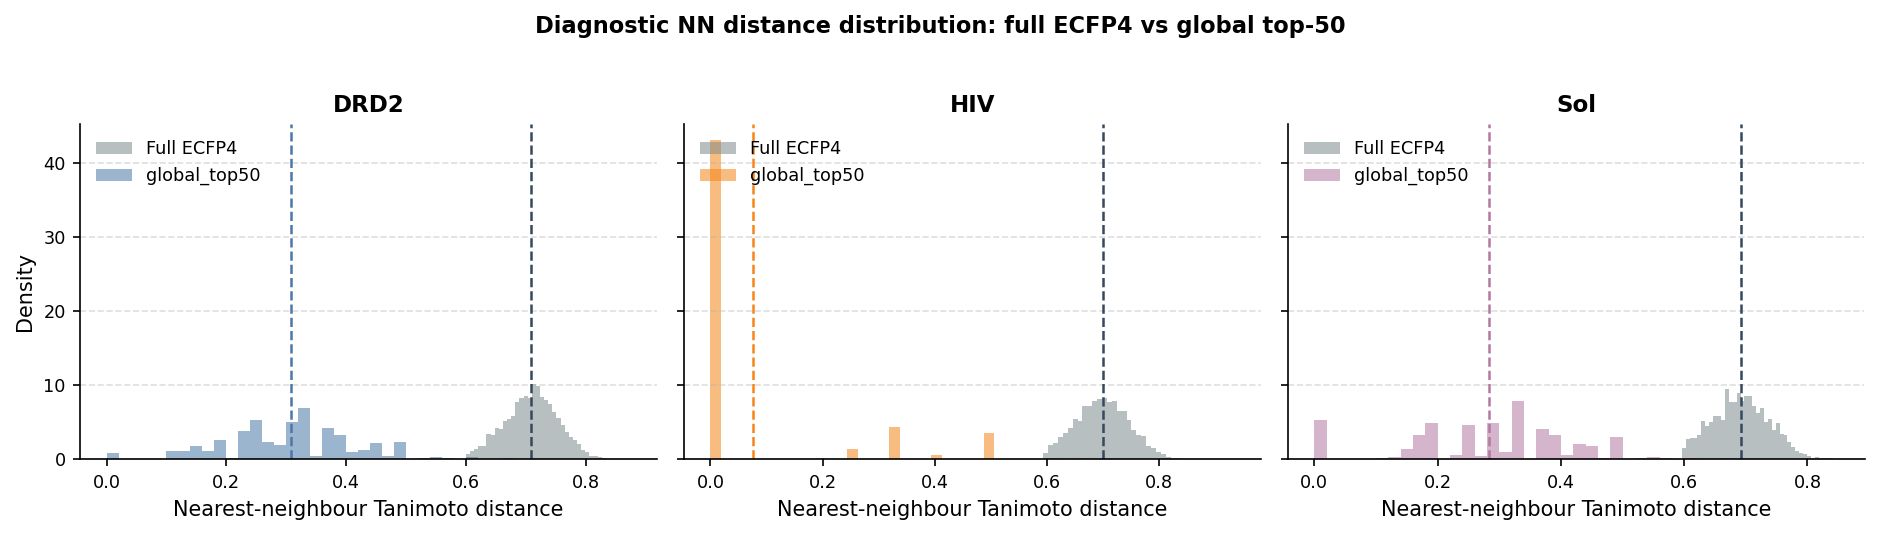

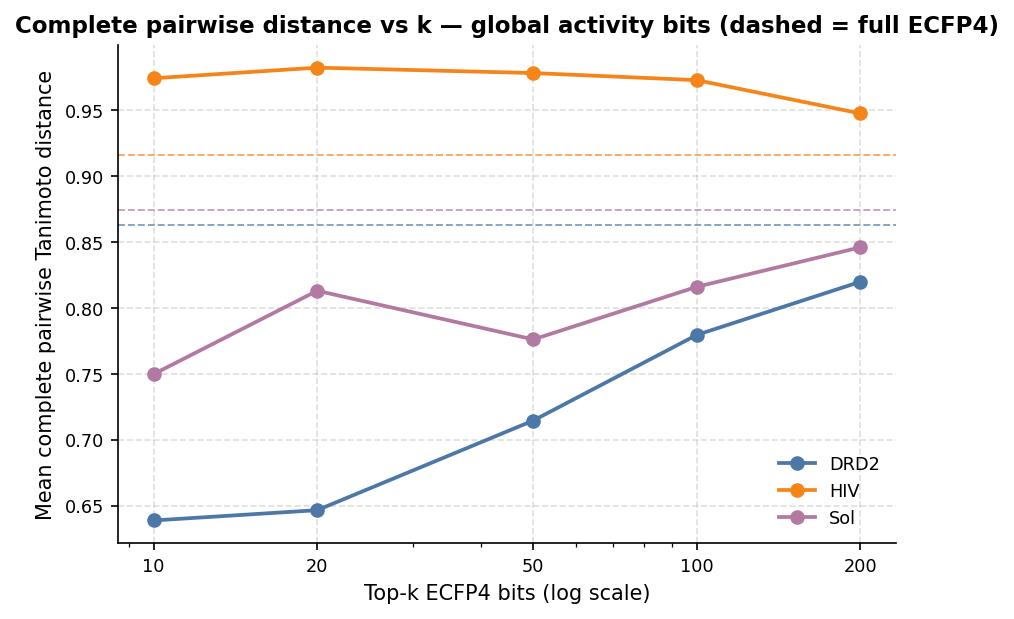

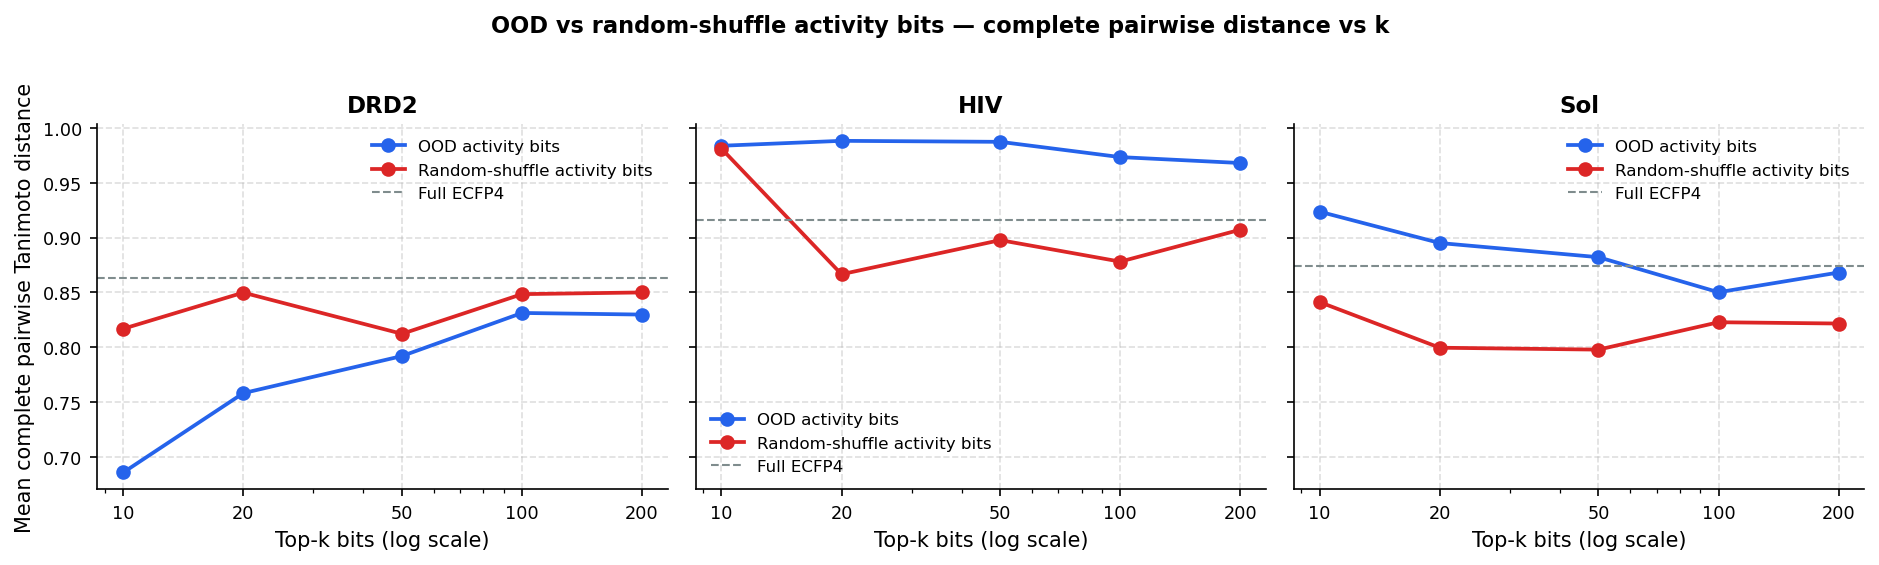

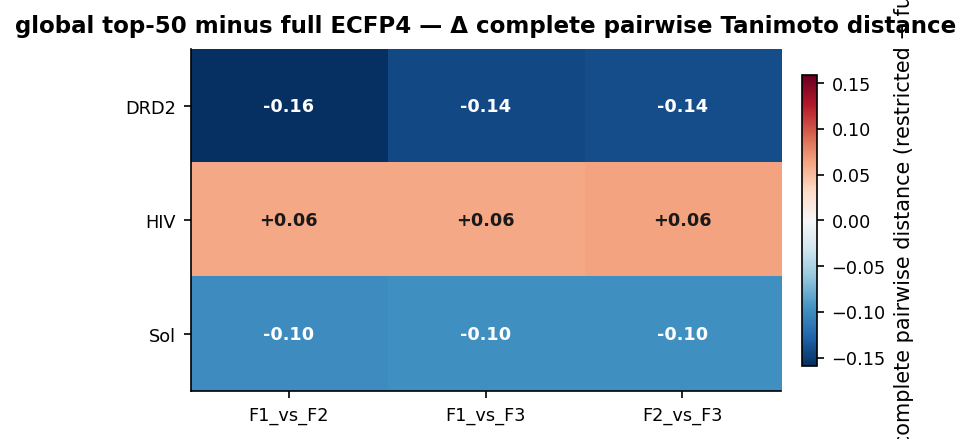

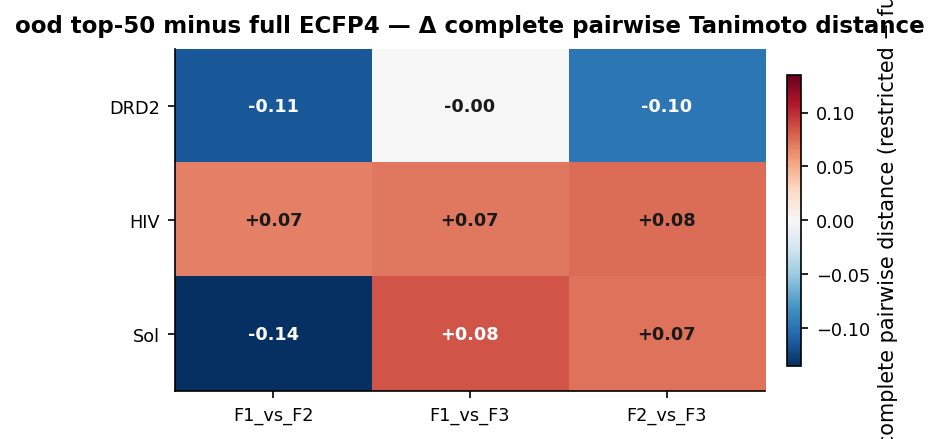

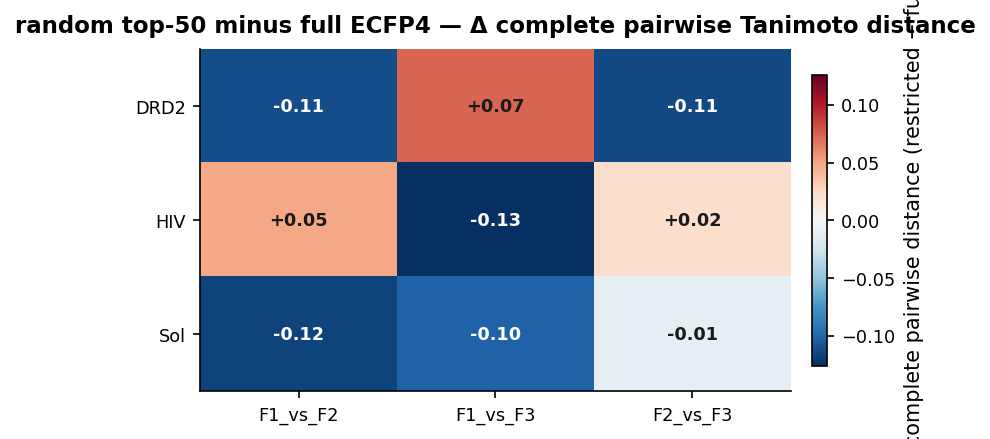

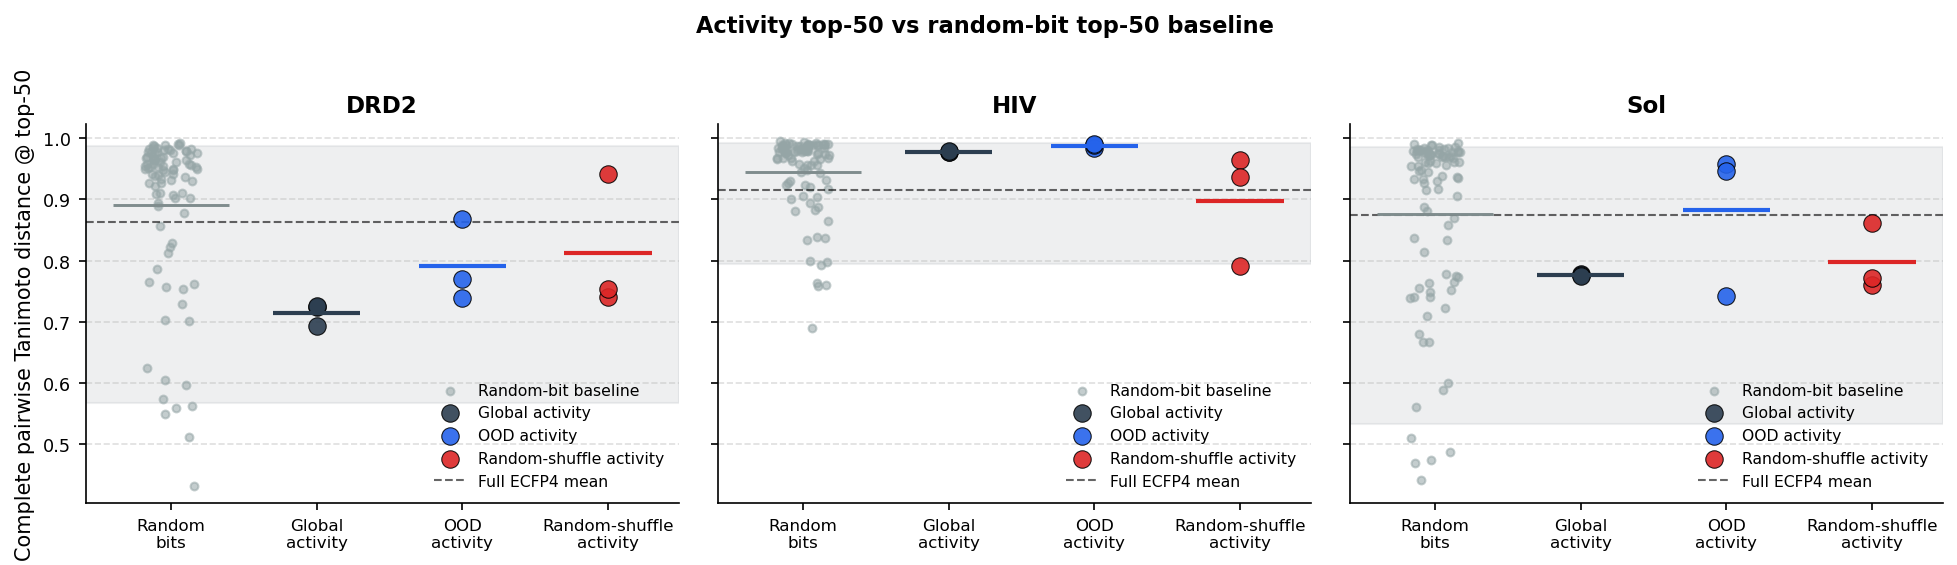

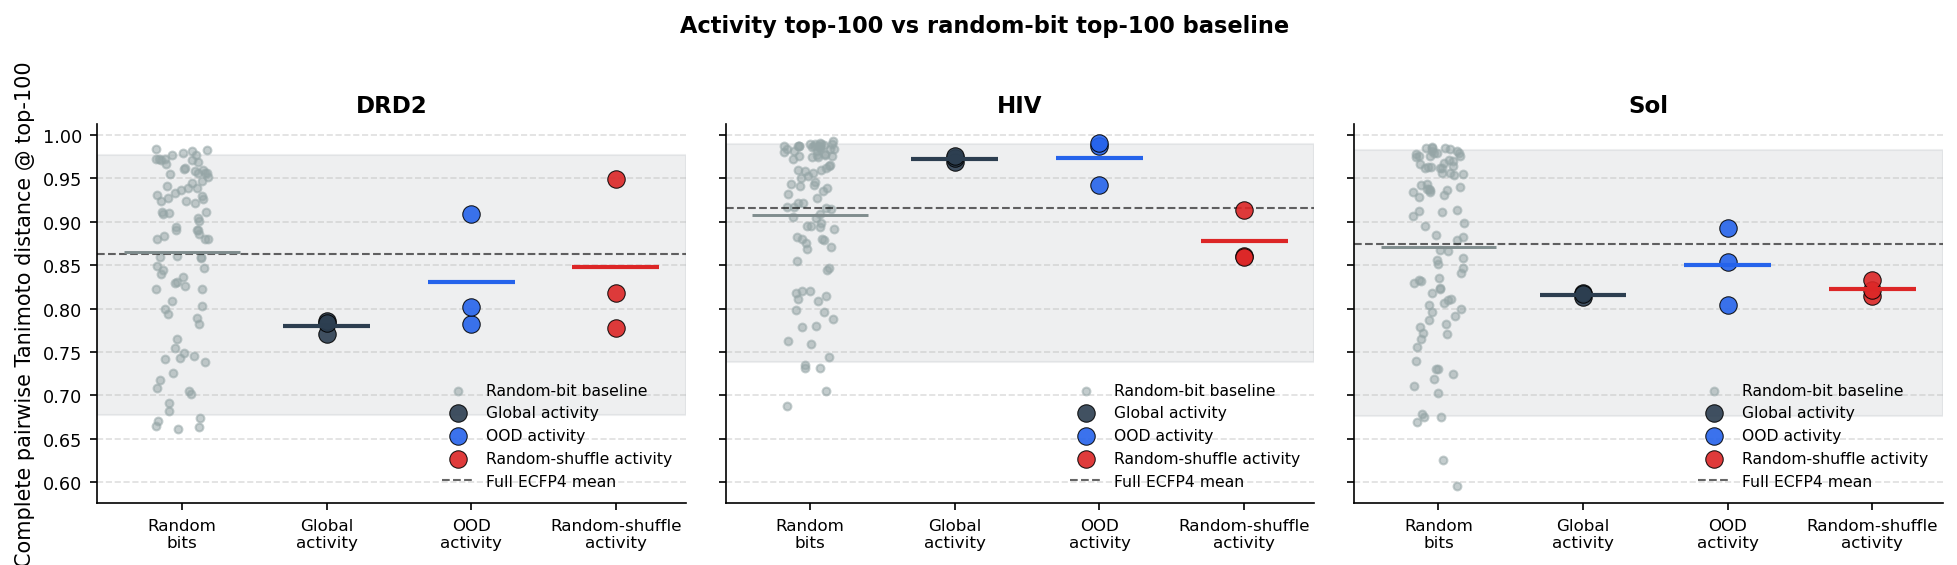

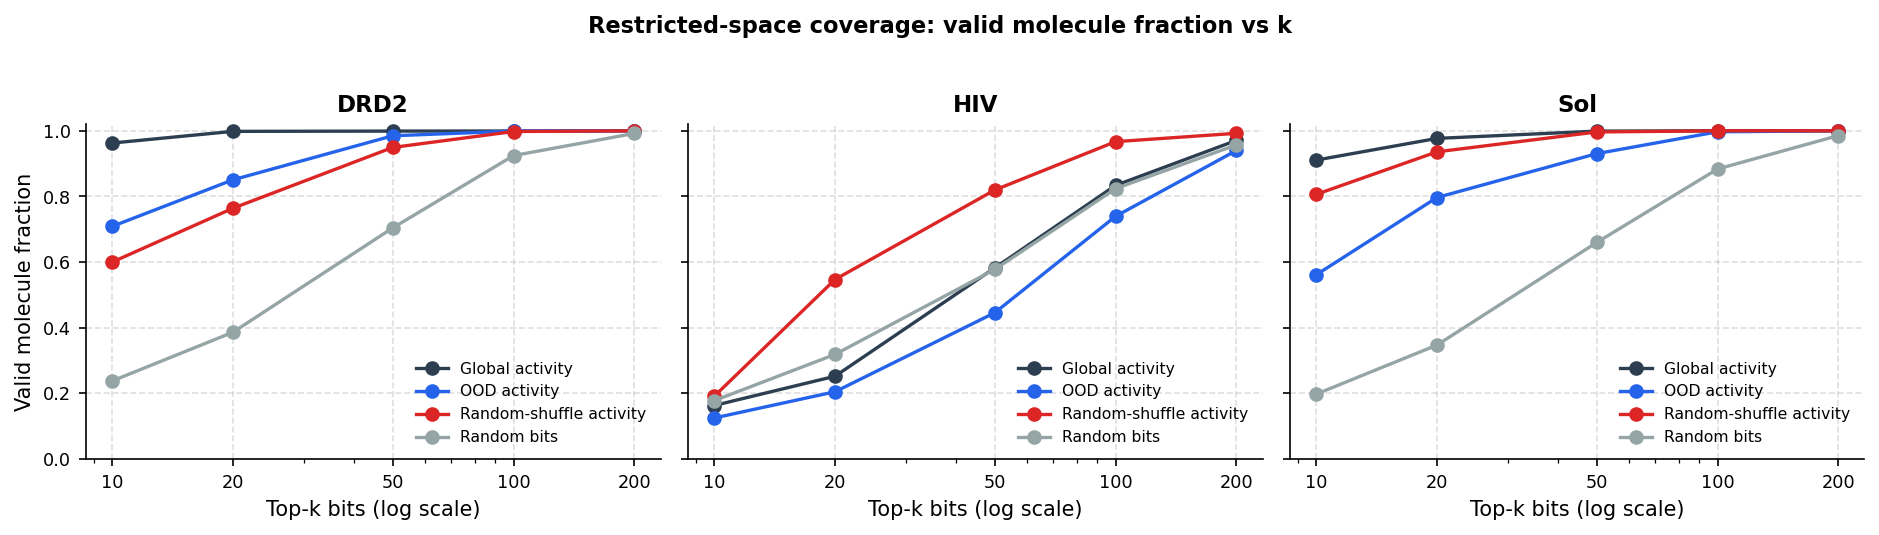


Done
Outputs saved in: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi
Figures saved in: /home/f.capria/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/figures
Finished fold-distance analysis.


In [23]:
print("Starting fold-distance analysis...")

dist_all, hist_all, final_summary = main()

print("Finished fold-distance analysis.")